# Bike Sharing Demand Forecasting - Exploratory Data Analysis

## Objective

The goal of this notebook is to understand the Bike Sharing dataset before any preprocessing or feature engineering.

During this notebook we will:

- Understand the structure of the dataset
- Explore data types
- Identify missing values
- Investigate the target variable
- Explore numerical and categorical features
- Detect potential data quality issues
- Identify opportunities for feature engineering

> **Note:** No modifications to the dataset will be performed in this notebook. Cleaning and preprocessing will be completed in Notebook 02.

# 1. Imports

In [1]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import catppuccin
from pathlib import Path

warnings.filterwarnings(action="ignore")
pd.set_option({"display.max_columns": None, "display.precision": 2})
plt.style.use("mocha")

# 2. Load the dataset

In [2]:
DF_PATH = Path("../data/raw/hour.csv")
df = pd.read_csv(DF_PATH)

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.29,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.27,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.27,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.29,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.29,0.75,0.0,0,1,1


# 3. Basic Information

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 17379
Columns: 17


In [4]:
# info
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


In [5]:
df.describe(include=["int64", "float64"]).T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.00,5017.03,1.00,4345.50,8690.00,13034.50,17379.00
season,17379.0,2.50,1.11,1.00,2.00,3.00,3.00,4.00
yr,17379.0,0.50,0.50,0.00,0.00,1.00,1.00,1.00
mnth,17379.0,6.54,3.44,1.00,4.00,7.00,10.00,12.00
hr,17379.0,11.55,6.91,0.00,6.00,12.00,18.00,23.00
holiday,17379.0,0.03,0.17,0.00,0.00,0.00,0.00,1.00
weekday,17379.0,3.00,2.01,0.00,1.00,3.00,5.00,6.00
workingday,17379.0,0.68,0.47,0.00,0.00,1.00,1.00,1.00
weathersit,17379.0,1.43,0.64,1.00,1.00,1.00,2.00,4.00
temp,17379.0,0.50,0.19,0.02,0.34,0.50,0.66,1.00


In [6]:
df.describe(include="object").T

,count,unique,top,freq
dteday,17379,731,2011-01-01,24


# 4. Missing Values

In [7]:
df.isna().sum().sort_values(ascending=False).to_frame(name="Missing Values")

,Missing Values
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


# 5. Duplicate Rows

In [8]:
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


# 6. Target Variable

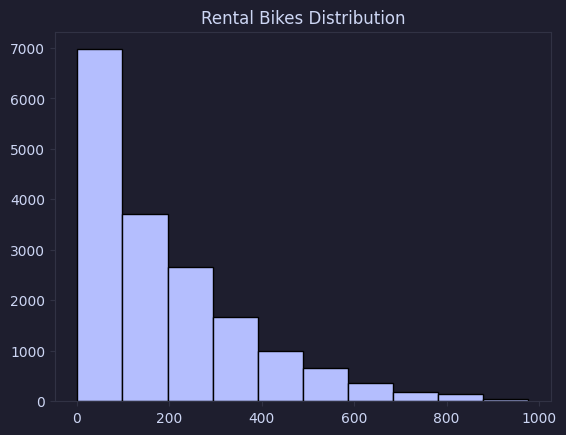

In [9]:
# histogram
plt.hist(df["cnt"], color=catppuccin.PALETTE.mocha.colors.lavender.hex, edgecolor="black")
plt.title("Rental Bikes Distribution")
plt.show()

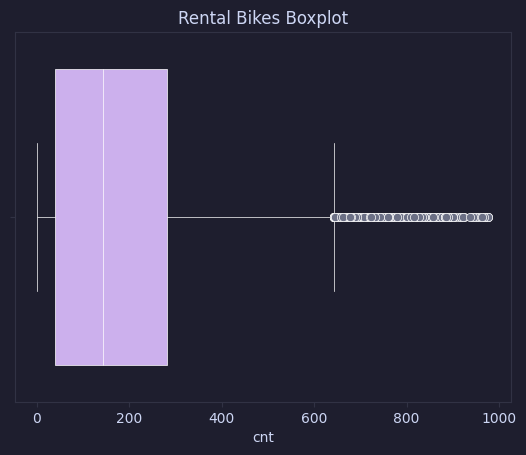

In [10]:
# boxplot
sns.boxplot(data=df, x="cnt", color=catppuccin.PALETTE.mocha.colors.mauve.hex, linecolor="white", linewidth=0.5, flierprops={"markeredgewidth": 0.5})
plt.title("Rental Bikes Boxplot")
plt.show()

# 7. Data Types

In [11]:
df.dtypes.value_counts()

int64      12
float64     4
str         1
Name: count, dtype: int64

## Observations

- `dteday` is of type `str` and will be converted to `datetime`

- `temp`, `atemp`, `hum` and `windspeed`are normalized and will likely be converted back to normal scale.

- The dataset doesn’t present missing values. As a result, no NaN filling will be used during cleaning. Furthermore, there are no duplicate rows.

- The statistics don’t show impossible values among numerical features. Values seem reasonable but will be further investigated.

- The target (`cnt`), which is the count of rental bikes, isn’t normally distributed as possible values are only positive.

- Most features in the data are integers (`int64` and `float64`), totaling 16 out of 17 total columns. The remaining one (`dteday`) is of type `str`.

- Since the dataset is small, performance improvement isn’t necessary but will be considered.

# 8. Numerical Features Analysis

In [12]:
numerical_features = ["temp", "atemp", "hum", "windspeed", "casual", "registered"]

# look at the numerical features
numerical_features

['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']

Summary Statistics

In [13]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,17379.0,0.50,0.19,0.02,0.34,0.50,0.66,1.00
atemp,17379.0,0.48,0.17,0.00,0.33,0.48,0.62,1.00
hum,17379.0,0.63,0.19,0.00,0.48,0.63,0.78,1.00
windspeed,17379.0,0.19,0.12,0.00,0.10,0.19,0.25,0.85
casual,17379.0,35.68,49.31,0.00,4.00,17.00,48.00,367.00
registered,17379.0,153.79,151.36,0.00,34.00,115.00,220.00,886.00


Distribution Plots

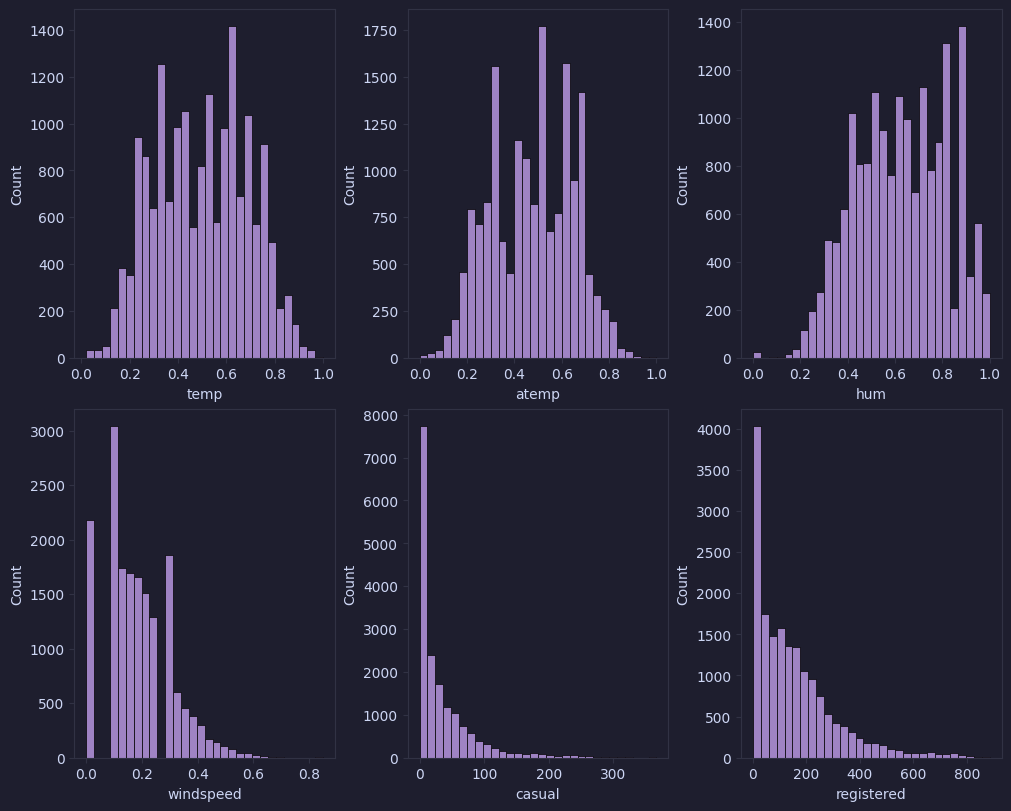

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=3, constrained_layout=True, figsize=(10, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(data=df, x=df[feature], color=catppuccin.PALETTE.mocha.colors.mauve.hex, edgecolor="black", bins=30, ax=axes[i])

plt.show()

Boxplots

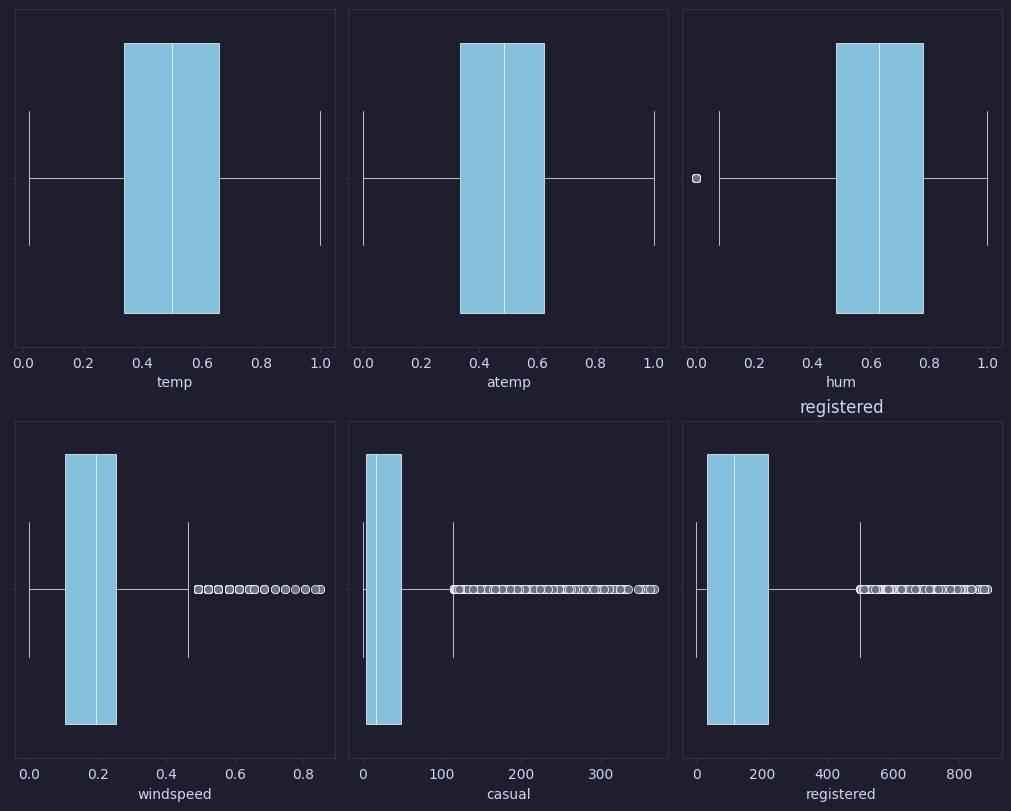

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=3, constrained_layout=True, figsize=(10, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(data=df, x=df[feature], ax=axes[i], color=catppuccin.PALETTE.mocha.colors.sapphire.hex, linecolor="white", linewidth=0.5, 
                flierprops={"markeredgewidth": 0.5})
    plt.title(feature)

plt.show()

Skewness

In [16]:
df[numerical_features].skew().sort_values(ascending=False)

casual        2.50e+00
registered    1.56e+00
windspeed     5.75e-01
temp         -6.02e-03
atemp        -9.04e-02
hum          -1.11e-01
dtype: float64

# Categorical Features Analysis

In [17]:
# select categorical variables
categorical_features = ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]

Inspection

In [18]:
for categorical_feature in categorical_features:
    print("-" * 60)
    print(categorical_feature)
    print(df[categorical_feature].value_counts().head())
    print()

------------------------------------------------------------
season
season
3    4496
2    4409
1    4242
4    4232
Name: count, dtype: int64

------------------------------------------------------------
yr
yr
1    8734
0    8645
Name: count, dtype: int64

------------------------------------------------------------
mnth
mnth
5     1488
7     1488
12    1483
8     1475
3     1473
Name: count, dtype: int64

------------------------------------------------------------
hr
hr
16    730
17    730
13    729
14    729
15    729
Name: count, dtype: int64

------------------------------------------------------------
holiday
holiday
0    16879
1      500
Name: count, dtype: int64

------------------------------------------------------------
weekday
weekday
6    2512
0    2502
5    2487
1    2479
3    2475
Name: count, dtype: int64

------------------------------------------------------------
workingday
workingday
1    11865
0     5514
Name: count, dtype: int64

-----------------------------------

Visualize the most important ones

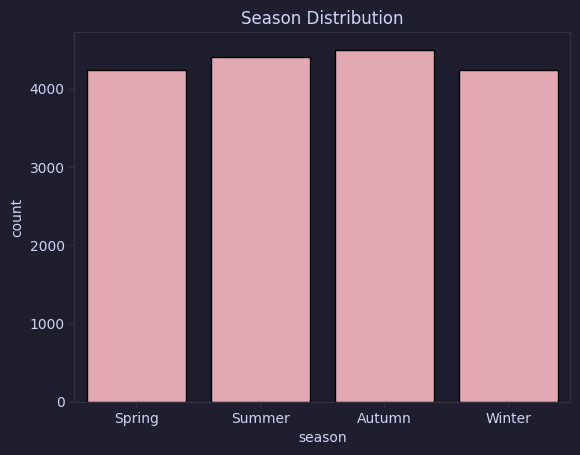

In [19]:
# season
sns.countplot(data=df, x="season", color=catppuccin.PALETTE.mocha.colors.maroon.hex, edgecolor="black")
plt.title("Season Distribution")
plt.xticks([0, 1, 2, 3], ["Spring", "Summer", "Autumn", "Winter"])
plt.show()

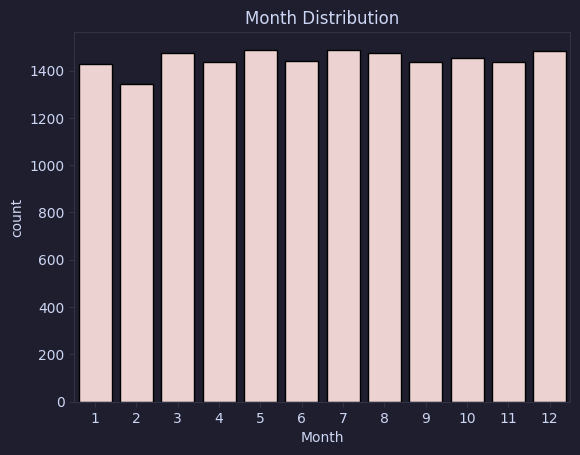

In [20]:
# month
sns.countplot(data=df, x="mnth", color=catppuccin.PALETTE.mocha.colors.flamingo.hex, edgecolor="black")
plt.title("Month Distribution")
plt.xlabel("Month")
plt.show()

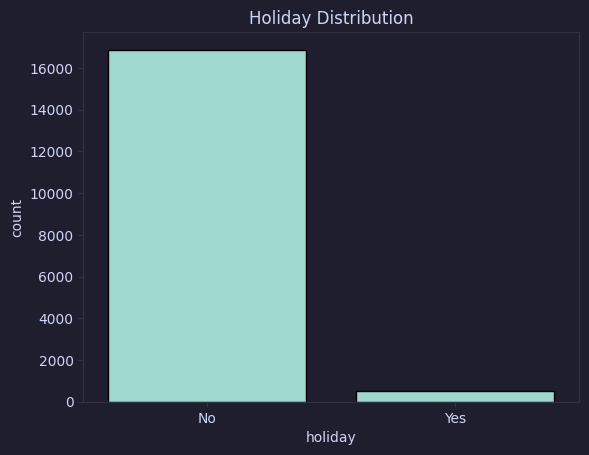

In [21]:
# holiday
sns.countplot(data=df, x="holiday", color=catppuccin.PALETTE.mocha.colors.teal.hex, edgecolor="black")
plt.title("Holiday Distribution")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

## Observations



Numerical features:
- They don’t exhibit unusual values as evidenced by non-negative values and reasonable maximum values.
- `casual` and `registered` aren’t normally distributed and show a few large positive values, indicating a few high counts of casual/registered users. This is further suggested by checking skewness values, with `casual` and `registered` having 2.50 and 1.56 skewness values, respectively.

Categorical features
- They don’t show unreasonable values with each value corresponding to its own category.
- Rental bike observations are roughly uniform per month. However, the dataset consists heavily of non-holiday days. Only a few entries are holiday days.

# 10. Relationship with the target (`cnt`)

Numerical features vs target

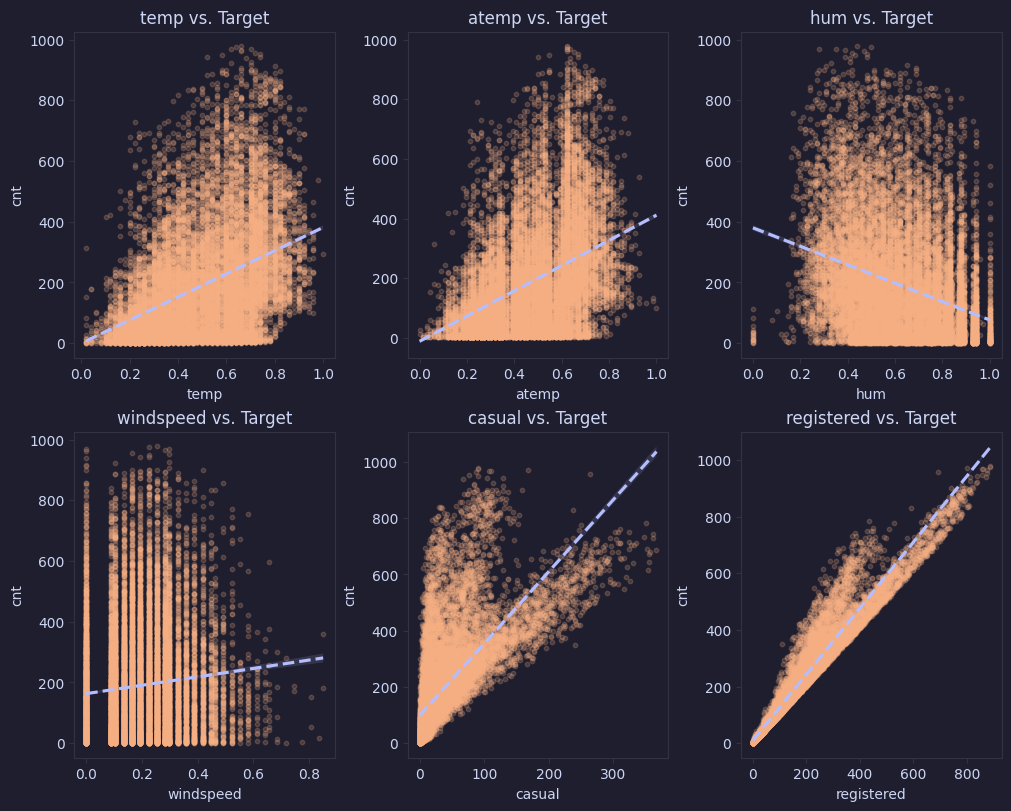

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=3, constrained_layout=True, figsize=(10, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.regplot(data=df, x=feature, y="cnt", color=catppuccin.PALETTE.mocha.colors.peach.hex, 
                scatter_kws={"s": 10, "alpha": 0.2}, line_kws={"color": catppuccin.PALETTE.mocha.colors.lavender.hex, "linestyle": "--"}, ax=axes[i])
    axes[i].set_title(f"{feature} vs. Target")

plt.show()

Categorical feature vs. Target

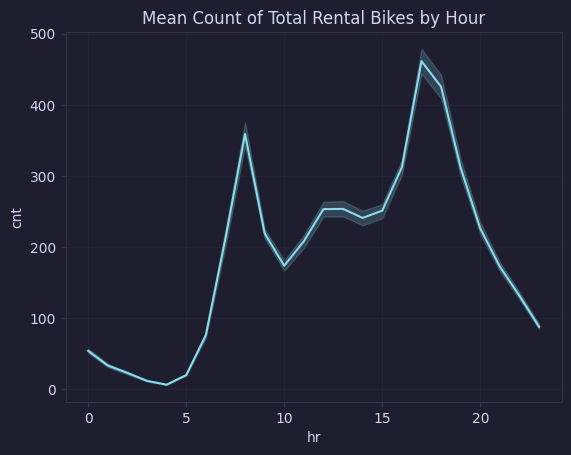

In [23]:
# mean cnt by hour
sns.lineplot(data=df, x="hr", y="cnt", estimator="mean", color=catppuccin.PALETTE.mocha.colors.sky.hex)
plt.title("Mean Count of Total Rental Bikes by Hour")
plt.grid(alpha=0.3)
plt.show()

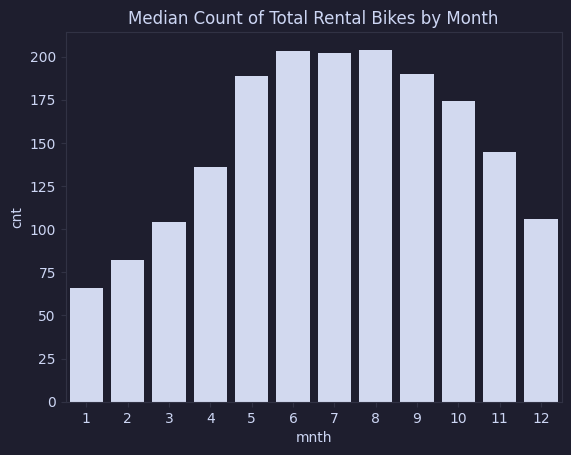

In [24]:
# mean cnt by month
sns.barplot(data=df, x="mnth", y="cnt", estimator="median", color=catppuccin.PALETTE.mocha.colors.text.hex, errorbar=None)
plt.title("Median Count of Total Rental Bikes by Month")
plt.show()

Correlation Analysis

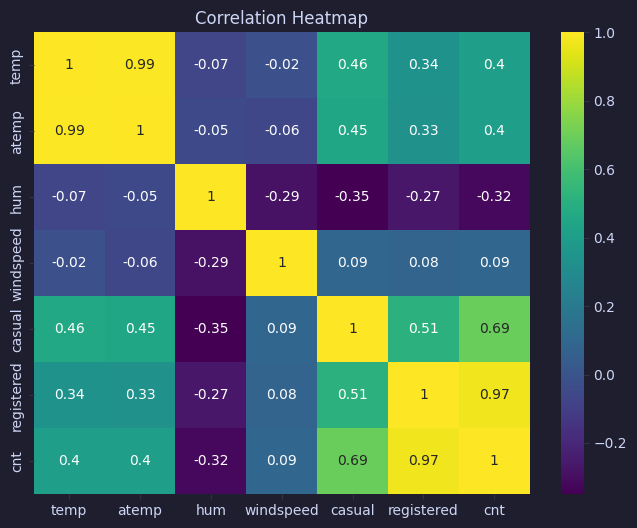

In [25]:
corr = df[numerical_features + ["cnt"]].corr(method="pearson").round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(data=corr, cmap="viridis", annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Observations

Numerical features vs. Target

- `casual` and `registered` show a high positive correlation with `cnt`, which is also confirmed by the correlation heatmap.

Categorical features vs. Target
- The average count of rental bikes per hour peaks at around 5pm (461.45) but the data presents also a lower peak at 8am (359.01). This probably suggests heavy use of bikes by people coming back from and going to work.
- The median count of total rental bikes starts in January and gradually increases until June. Summer represents the most popular season according to the data. After August, rental bikes gradually decrease until the end of the year. 

Correlation Analysis
- The most correlated features with `cnt` are `registered` (0.97) and `casual` (0.69). This is expected as the target contains the count of total rental bikes for both casual and registered users.

## Feature Engineering Ideas
- Engineer lag features such as `cnt_lag_1`, `cnt_lag_24` and `cnt_lag_168`.
- Create cyclical encodings such as `hour_sin`, `hour_cos`, `month_sin` and `month_cos`.
- Convert `dteday` to `datetime` format and engineer `year`and `day` from it.
- Missing values won’t be filled as there are none.
- `temp`, `atemp`, `hum` and `windspeed` are normalized and might be converted back to original values.
- `casual` and `registered` will be removed due to target leakage.